# **Emerging Technologies Problems Notebook**

## **Introduction**

This notebook walks through [Deutsch's algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm) and its generalisation, the Deutsch–Jozsa algorithm. As noted in the IBM Quantum documentation, the [Deutsch–Jozsa algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa) was one of the first known quantum algorithms that showed an exponential speedup compared to a deterministic classical algorithm, given a black-box oracle function. We'll build up the full picture step by step — starting with the classical problem, then constructing quantum oracles, and finally assembling the quantum circuits that solve it in a single query.

**Deutsch's Algorithm vs The Deutsch–Jozsa Algorithm**

Both algorithms solve the same fundamental problem — determining whether a Boolean function is constant or balanced — but they differ in **scale**.

**Deutsch's algorithm** is the simpler case. It works with a function that takes a **single Boolean input**, meaning there are only 4 possible functions to consider (as shown in the table above). The algorithm uses a 2-qubit circuit and determines the function type in a single query, compared to the 2 queries required classically.

**The Deutsch–Jozsa algorithm** is the generalisation of Deutsch's approach to functions with **n Boolean inputs**. In this notebook, we work with n = 4, giving 2⁴ = 16 possible input combinations. The algorithm still determines the function type in a **single query**, regardless of how many input bits are used — while classically, you would need up to 2ⁿ⁻¹ + 1 = 9 queries to be certain.

The table below summarises the difference:

| | Deutsch's Algorithm | Deutsch–Jozsa Algorithm |
|:---|:---:|:---:|
| Number of input bits | 1 | n (here, n = 4) |
| Possible input combinations | 2 | 2ⁿ (here, 16) |
| Quantum queries needed | 1 | 1 |
| Classical queries needed (worst case) | 2 | 2ⁿ⁻¹ + 1 (here, 9) |
| Qubits required | 2 | n + 1 (here, 5) |

This notebook works through both algorithms in order — starting with Deutsch's algorithm as a foundation, then scaling up to the full Deutsch–Jozsa algorithm. The core ideas (superposition, phase kickback, and interference - discussed later) are the same in both cases; the Deutsch–Jozsa algorithm simply applies them at a larger scale.

**The Core Problem**

Imagine someone hands you a black box (called an **oracle**). The box takes an input and spits out either 0 or 1. You're told the box is guaranteed to be a function of one of two types:

* Constant: always outputs the same thing (always 0, or always 1), no matter what you put in
* Balanced: outputs 0 for exactly half the possible inputs, and 1 for the other half

***Deutsch and Deutsch-Josza algorithms: used to figure out which type it is*** 

The question both the Deutsch and Deutsch-Josza algorithms answer is: how many times do you need to query the box in order to find out which type of function it is?

In [ ]:
# imports used in this notebook
import random
from itertools import product
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from IPython.display import display

## Problem 1: Generating Random Boolean Functions

### **Introduction**

Before we can test any algorithm, we need something to test it on. This first problem sets up the playground: a way to randomly generate the kinds of functions that Deutsch–Jozsa is designed to classify.

***What kind of functions are we dealing with?***
The type of function that the Deutsch and Deutsch–Jozsa algorithms are meant to classify is known as a Boolean function. As described in the official Python documentation, a [Boolean function](https://docs.python.org/3/c-api/bool.html) takes one or more binary inputs and returns a single binary output. The inputs and outputs can only ever be one of two values — in mathematics and circuit diagrams these are written as **1** and **0**, while in Python they are written as **True** and **False**.

These two notations mean exactly the same thing.

For a function with a **single** Boolean input, there are exactly four possible functions:

| Function | f(0) | f(1) | f(False) | f(True) | Type |
|:---:|:---:|:---:|:---:|:---:|:---:|
| f₁ | 0 | 0 | False | False | Constant |
| f₂ | 1 | 1 | True | True | Constant |
| f₃ | 0 | 1 | False | True | Balanced |
| f₄ | 1 | 0 | True | False | Balanced |


For this notebook, we're working with functions that take four Boolean inputs — call them a, b, c, d — and return one Boolean value.
With four inputs, there are 2⁴ = 16 possible input combinations, ranging from (False, False, False, False) all the way to (True, True, True, True).

The Deutsch and Deutsch–Jozsa algorithms are built around a guarantee: the function you're given is promised to be one of two types:

* Constant — it returns the same value (always True, or always False) no matter what inputs you give it.
* Balanced — it returns True for exactly half the inputs (8 out of 16) and False for the other half.

The algorithm determines whether the given function is constant or balanced. A constant function maps all inputs to 0 or 1, and a balanced function maps half of its inputs to 0 and the other half to 1. There's no in-between and the algorithm's job is to figure out which type it is.

### **random_constant_balanced() function:**

The function random_constant_balanced acts as a function factory: each time it is called, it randomly constructs and returns one of these promised functions (constant or balanced). Here is the logic in plain terms:

* **Step 1** — constant or balanced: It uses random.choice() to randomly decide whether to make a constant or a balanced function (50/50 chance either way). The random module provides uniform selection of a random element from a sequence, as described in the [Python documentation](https://docs.python.org/3/library/random.html#random.choice)
* **Step 2a** — If constant: It picks a fixed output value (True or False) at random, then returns a function that always outputs that value, completely ignoring its inputs.
* **Step 2b** — If balanced: It lists all 16 possible input combinations using [itertools.product()](https://docs.python.org/3/library/itertools.html#itertools.product). To compute the product of an iterable with itself, you specify the number of repetitions with the optional repeat keyword argument — for example, product(A, repeat=4) means the same as product(A, A, A, A). It then uses [random.sample()](https://docs.python.org/3/library/random.html#random.sample) to pick exactly 8 of those 16 combinations to be the "True" inputs. The result is stored as a Python set for fast lookup, and the function checks whether its input belongs to that set.

Why a set and not a list? Membership testing — checking whether a value is in a collection — has very different performance depending on the data structure. According to the [Python Wiki on Time Complexity](https://wiki.python.org/python/TimeComplexity.html), set membership testing runs in O(1) average time, meaning it's equally fast regardless of how many items the set contains. A list, by contrast, requires scanning through every element, making it slower as the list grows. Since our function may be called many times, the set is the right choice here.

**A note on closures:** Both inner functions (constant_function and balanced_function) rely on a Python feature called a closure — a nested function that retains access to variables defined in its enclosing scope. You can read more about how Python handles this in the Python language reference on naming and binding. This is what allows value or true_inputs to be "baked in" at the time the function is created, so the returned function remembers its configuration even after random_constant_balanced has finished running.

In [4]:
def random_constant_balanced():
    """
    Generate and return a random Boolean function of four inputs that satisfies
    the Deutsch-Jozsa promise.

    Returns:
        function: A callable f(a, b, c, d) -> bool, which is either constant or balanced.
    """
    # Decide whether function is constant or balanced
    is_constant = random.choice([True, False])
    
    # constant case: all outputs are the same (either all True or all False)
    if is_constant:
        # Randomly select the fixed output value the function will always return (will be either True or False)
        value = random.choice([True, False])
        
        # Define the constant inner function - accepts all four Boolean inputs
        def f(a, b, c, d):
            # ignores inputs & returns the same pre-selected value
            return value
        # Return the constant function itself (not its result) so the caller receives a callable they can query with any inputs
        return f
    
    # balanced case: exactly half of the outputs are True and half are False
    else:        
        # Generate all 16 input combinations
        inputs = list(product([False, True], repeat=4))
        
        # Randomly choose 8 combinations to return True
        true_inputs = set(random.sample(inputs, 8))
        
        # Define the balanced inner function - accepts all four Boolean inputs and checks if the combination is in the set of true_inputs to determine its output
        def f(a, b, c, d):
            # checks whether the tuple is one of the 8 selected 'True' inputs using the membership test (in) 
            # returns True if the tuple is in true_inputs and False otherwise.
            return (a, b, c, d) in true_inputs
        # Return the balanced function itself (not its result) so the caller receives a callable they can query with any inputs
        return f

### **Problem 1 Testing**

**Tests for random_constant_balanced()**

**Test:** Show the output of a randomly generated function across all 16 inputs. 

This test calls random_constant_balanced() once to generate a random function then queries it with every possible combination of four Boolean inputs.The results are printed as a truth table, and the function type (constant or balanced) is determined by counting how many outputs are True.

**Note:** Re-run this cell to see a different randomly generated function. You should see a mix of constant and balanced functions appear over multiple runs, with roughly equal probability of each type.

In [5]:
# =============================================================================
# Tests for random_constant_balanced()
# =============================================================================

# Test: Show the output of a randomly generated function across all 16 inputs

print("=" * 40)
print("Test: Output table for a random function")
print("=" * 40)

# Generate a single random function — either constant or balanced
f = random_constant_balanced()

# Print the truth table header
print(f"{'a':>2} {'b':>2} {'c':>2} {'d':>2}  ->  output")
print("-" * 28)

# Query the function with all 16 possible input combinations and record outputs
outputs = []
for a, b, c, d in product([0, 1], repeat=4):
    # Call the function with the current input combination
    out = f(a, b, c, d)
    # Store the output for later analysis
    outputs.append(out)
    # Print the input combination and its corresponding output as 0 or 1
    print(f"{a:>2} {b:>2} {c:>2} {d:>2}  ->  {int(out)}")

# Count how many outputs were True (i.e. 1)
true_count = sum(outputs)

# Determine function type:
# - Constant: all 16 outputs are the same (true_count is 0 or 16)
# - Balanced: exactly 8 outputs are True and 8 are False (true_count is 8)
function_type = "constant" if true_count in (0, 16) else "balanced"

print(f"\nTrue outputs: {true_count}/16  ->  Function is {function_type}\n")

Test: Output table for a random function
 a  b  c  d  ->  output
----------------------------
 0  0  0  0  ->  0
 0  0  0  1  ->  0
 0  0  1  0  ->  0
 0  0  1  1  ->  0
 0  1  0  0  ->  0
 0  1  0  1  ->  0
 0  1  1  0  ->  0
 0  1  1  1  ->  0
 1  0  0  0  ->  0
 1  0  0  1  ->  0
 1  0  1  0  ->  0
 1  0  1  1  ->  0
 1  1  0  0  ->  0
 1  1  0  1  ->  0
 1  1  1  0  ->  0
 1  1  1  1  ->  0

True outputs: 0/16  ->  Function is constant



## **Problem 2: Classical Testing for Function Type**

### **Introduction**

Now that we can generate random constant or balanced functions, the next step is to
write a **classical** solution that can determine which type a given function is. This
is important because it gives us a baseline to compare against — understanding the
classical cost of solving this problem is exactly what motivates the quantum approach.

**What does "classical" mean here?**

[A classical solution](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm) can only query the function **one input at a time**. There is no
superposition, no interference — just straightforward calls to `f(a, b, c, d)` and
comparing the results. This is how any ordinary computer program would approach the
problem, and it is the standard against which quantum algorithms are measured.

The key insight is this: you do not always need to check all 16 inputs. If you query
the function twice and get **different outputs**, you already know it must be balanced as a constant function can never return two different values. The worst case is when the
function keeps returning the same output, forcing you to keep querying until you can be
certain.

**How many queries are needed?**

In the worst case, you need **9 queries** to be 100% certain. Here is why:

- If you have seen the same output for the first 8 queries, the function could still be
  balanced — there exist balanced functions that return the same value for up to 8
  consecutive inputs.
- Only when the **9th query** returns the same value can you be certain the function is
  constant, because a balanced function returns `True` for exactly 8 of the 16 inputs
  and cannot return the same value more than 8 times.
- If at any point two queries return **different values**, you can immediately stop and
  conclude the function is balanced.

| Scenario | Queries needed |
|:---|:---:|
| Best case (two different outputs seen immediately) | 2 |
| Worst case (must be certain the function is constant) | 9 |

This worst case of 9 classical queries is exactly what the
[Deutsch–Jozsa algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa)
reduces to a **single quantum query** — and that is the quantum advantage.

### **determine_constant_balanced() function**

The function `determine_constant_balanced` takes a function `f` (as generated by
`random_constant_balanced`) and returns the string `"constant"` or `"balanced"`
depending on the result of its analysis.

It works by querying `f` across all 16 possible input combinations and counting how many times it returns `True`. The logic follows directly from the definitions of constant and balanced functions:

- If `f` returns `True` for **all 16 inputs** or `False` for **all 16 inputs** → the output never changes, so the function must be **constant**.
- If `f` returns `True` for **exactly 8 inputs** and `False` for the other 8 → the function must be **balanced**.

Since the Deutsch–Jozsa promise guarantees the function is one of these two types, no other cases need to be handled. The implementation uses [itertools.product()](https://docs.python.org/3/library/itertools.html#itertools.product) to generate all 16 input combinations, consistent with how they are generated in `random_constant_balanced()`.

**Implementation:**

* Step 1: Generate all 2^4 = 16 possible 4-tuple Boolean input combinations using product([False, True], repeat=4) and store them in a list.
* Step 2: Initialise a counter true_count to zero to track how many inputs cause f to return True.
* Step 3: Iterate over every input combination, calling f(*inp) for each, and increment true_count whenever f returns True.
* Step 4: After all 16 evaluations, check true_count: if it is 0 or 16, return "constant"; otherwise return "balanced".

#### **Efficiency: Classical vs Quantum**


The difference in cost between the classical and quantum approaches is stark, and it is important to understand precisely why.

Any **deterministic classical algorithm** that correctly solves the Deutsch–Jozsa problem must (in the worst case) make exponentially as many queries. As described in the [IBM Quantum Learning documentation](https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/quantum-query-algorithms), if a deterministic algorithm queries f on 2ⁿ⁻¹ or fewer different inputs and obtains the same function value every time, both answers are still possible — the function might be constant, or it might be balanced but through bad luck the queries all happened to return the same value. This means a deterministic classical algorithm requires at least **2ⁿ⁻¹ + 1** queries in the worst case before it can be certain.

For our four-input case (n = 4), this gives a worst case of 2³ + 1 = **9 queries**.

The [Deutsch–Jozsa algorithm](https://docs.quantum.ibm.com/api/qiskit/0.29/qiskit.aqua.algorithms.DeutschJozsa) by contrast, always gives the correct answer when the promise is met, and does so with a **single query** — regardless of how many input bits the function takes. This is not a probabilistic shortcut or an approximation; it is a provably correct result achieved through quantum superposition and interference. The quantum advantage grows exponentially with n:

| n (input bits) | Classical worst case | Quantum queries |
|:---:|:---:|:---:|
| 1 | 2 | 1 |
| 2 | 3 | 1 |
| 3 | 5 | 1 |
| 4 (this notebook) | 9 | 1 |
| n | 2ⁿ⁻¹ + 1 | 1 |

This exponential separation between classical and quantum query complexity is precisely what makes the Deutsch–Jozsa algorithm historically significant — it was one of the first clean, provable demonstrations that quantum computers can solve a well-defined problem exponentially faster than any classical deterministic algorithm.

In [6]:
def determine_constant_balanced(f):
    """
    Determines whether a given 4-input Boolean function f
    is constant or balanced.

    The function is guaranteed (by the Deutsch-Jozsa promise) to be one of these
    two types, so no other cases need to be handled.

    Args:
        f (callable): A function f(a, b, c, d) -> bool, as generated by
                      random_constant_balanced(). Must satisfy the Deutsch-Jozsa
                      promise of being either constant or balanced.

    Returns:
        str: "constant" if f returns the same value for all inputs,
             "balanced" if f returns True for exactly half of all inputs.
    """

    # Generate all 16 possible input combinations for four Boolean variables
    inputs = list(product([False, True], repeat=4))

    # Counter to track how many times f returns True.
    true_count = 0

    # query f with every possible input combination and accumulate the True count
    for inp in inputs:
        # Unpack the tuple (a, b, c, d) into four separate arguments using *
        if f(*inp):
            # Increment true_count each time f returns True
            true_count += 1
            
    # If f returned True for all 16 inputs or for none of them (every output was the same) the function is constant
    if true_count == 0 or true_count == 16:
        # return "constant"
        return "constant"
    else:
        # Since the problem guarantees constant or balanced,
        # the only remaining possibility is balanced (8 True, 8 False)
        return "balanced"

### **Problem 2 Testing**

**Test: Verify `determine_constant_balanced()` on a randomly generated function**

This test generates a random function using `random_constant_balanced()`, prints its
full truth table, and checks whether `determine_constant_balanced()` correctly
identifies its type by comparing the classification against the actual output
distribution.

**Note:** Re-run this cell to test on a different randomly generated function. Over
multiple runs you should see both constant and balanced functions being correctly
identified.

In [7]:
# =============================================================================
# Test for determine_constant_balanced()
# =============================================================================
# Test: Generate a random function, display its truth table, and verify the
#       classification matches the actual output distribution.
print("=" * 40)
print("Test: Classical classification of a random function")
print("=" * 40)

# Generate a single random function — either constant or balanced
f = random_constant_balanced()

# Print the truth table header
print(f"{'a':>2} {'b':>2} {'c':>2} {'d':>2}  ->  output")
print("-" * 28)

# Query f with all 16 input combinations and record the outputs
outputs = []
for a, b, c, d in product([0, 1], repeat=4):
    # Call the function with the current input combination
    out = f(a, b, c, d)
    # Store the output for later verification
    outputs.append(out)
    # Print the current input and its corresponding output as 0 or 1
    print(f"{a:>2} {b:>2} {c:>2} {d:>2}  ->  {int(out)}")

# Count how many outputs were True to determine the actual function type.
# - Constant: true_count is 0 (always False) or 16 (always True)
# - Balanced: true_count is exactly 8
true_count = sum(outputs)
actual_type = "constant" if true_count in (0, 16) else "balanced"

# Run determine_constant_balanced() to get its classification
classified_type = determine_constant_balanced(f)

# Print the results and compare
print(f"\nTrue outputs : {true_count}/16")
print(f"Actual type  : {actual_type}")
print(f"Classified as: {classified_type}")

# Confirm whether the classification matches the actual type
if classified_type == actual_type:
    print(f"\nPASS: determine_constant_balanced() correctly identified the function as {actual_type}")
else:
    print(f"\nFAIL: Expected '{actual_type}' but got '{classified_type}'")

Test: Classical classification of a random function
 a  b  c  d  ->  output
----------------------------
 0  0  0  0  ->  0
 0  0  0  1  ->  0
 0  0  1  0  ->  0
 0  0  1  1  ->  0
 0  1  0  0  ->  0
 0  1  0  1  ->  0
 0  1  1  0  ->  0
 0  1  1  1  ->  0
 1  0  0  0  ->  0
 1  0  0  1  ->  0
 1  0  1  0  ->  0
 1  0  1  1  ->  0
 1  1  0  0  ->  0
 1  1  0  1  ->  0
 1  1  1  0  ->  0
 1  1  1  1  ->  0

True outputs : 0/16
Actual type  : constant
Classified as: constant

PASS: determine_constant_balanced() correctly identified the function as constant


## **Problem 3: Quantum Oracles**

### **Introduction**

In **Problems 1 and 2**, we worked entirely in the classical world — generating [Boolean functions](https://docs.python.org/3/c-api/bool.html) and determining their type by querying them one input at a time. In that setting, each input is evaluated separately, so learning about a function can require multiple queries.

In problem 3, we introduce how quantum computing changes this paradigm through the principle of [superposition](https://quantum.cloud.ibm.com/learning/en/modules/quantum-mechanics/superposition-with-qiskit). A qubit (quantum bit) is not limited to being just $|0\rangle$ or $|1\rangle$ - it can exist in a linear combination of both states simultaneously: ∣ψ⟩=α∣0⟩+β∣1⟩
* Where $\alpha$ and $\beta$ are complex amplitudes satisfying $|\alpha|^2 + |\beta|^2 = 1$. 

This means that a quantum system can represent multiple inputs at once.

When a function is evaluated on a qubit in superposition, the function is effectively applied to all components of the superposition simultaneously. However, to make use of this superposition, the Boolean functions from **Problem 1** must be translated into a form a quantum computer can use. Problem 3 is where the transition to quantum computing is made: to use a classical function inside a quantum circuit, it needs to be translated into a [quantum oracle](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-jozsa-algorithm).

**A quantum oracle:** is a black-box unitary operation that encodes a classical function **f: {0,1} → {0,1}** into a quantum circuit. Each oracle acts on two qubits (quantum bits) using the transformation:

$$U_f\,|x\rangle|y\rangle \;=\; |x\rangle|y \oplus f(x)\rangle$$
 
Where x is the input qubit and y is the ancilla qubit. 

**XOR**-ing the ancilla with f(x) rather than overwriting it keeps the operation reversible, which is a requirement for all quantum gates. The four oracles implemented here will be used in **Problem 4** to demonstrate Deutsch's algorithm, which determines whether a function is constant or balanced using only a single oracle call.

This section implements the four possible single-qubit Boolean oracles that satisfy the Deutsch–Jozsa promise — two constant and two balanced — as Qiskit circuit operations. Each oracle applies a different sequence of quantum gates to implement its corresponding function's XOR transformation, and together they form the complete oracle set over which the quantum algorithm will be tested. To achieve this, this section implements four oracle functions:

* oracle_f0(qc, x, y): Constant zero — f(x)=0
* oracle_f1(qc, x, y): Constant one — f(x)=1
* oracle_f2(qc, x, y): Identity / balanced — f(x)=x
* oracle_f3(qc, x, y): Negation / balanced — f(x)=NOT x

Each oracle is implemented as a Python function that takes a [QuantumCircuit](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.QuantumCircuit) object `qc` along with qubit references `x` (input) and `y` (ancilla/output), and applies the appropriate gates directly to the circuit. The gates used are:

- **[X gate (Pauli-X)](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.XGate)** — the quantum equivalent of a classical NOT gate. Flips $|0\rangle \leftrightarrow |1\rangle$ unconditionally.
- **[CNOT gate (Controlled-X)](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.CXGate)** — flips the target qubit if and only if the control qubit is $|1\rangle$.


### **oracle_f0() - constant zero function:**

``oracle_f0`` implements the constant zero function ``f(x) = 0``. Since ``f(x) = 0`` for all x, the oracle transformation becomes:

$$U_{f_0}\,|x\rangle|y\rangle = |x\rangle|y \oplus 0\rangle = |x\rangle|y\rangle$$

XOR-ing with 0 leaves y unchanged. As a result, neither qubit is modified and no gates are needed. This is the simplest possible oracle and serves as a useful baseline: any circuit that applies ``oracle_f0`` is unchanged by it.

* **Step 1:** Receive the quantum circuit qc and qubit indices x and y.
* **Step 2:** Apply no gates: y⊕0=y requires no operation.
* **Step 3:** Return the unmodified circuit.

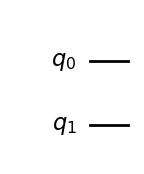

In [8]:
# f(x) = 0  (constant function)
def oracle_f0(qc, x, y):
    """
    f0(x) = 0  (constant zero)
    
    Oracle action: |x⟩|y⟩ → |x⟩|y XOR 0⟩ = |x⟩|y⟩
    """
    
    # Does nothing because f(x) = 0 -> y XOR 0 = y
    # Return unmodified circuit 
    return qc

# Display the circuit for oracle_f0
# Expected: an empty circuit — no gates are applied
display(oracle_f0(QuantumCircuit(2), 0, 1).draw('mpl'))

### **oracle_f1(qc, x, y) - constant one function:**

The following function implements the constant one function ``f(x) = 1`` -> since ``f(x) = 1`` for all x, the oracle transformation becomes:

$$U_{f_1}\,|x\rangle|y\rangle = |x\rangle|y \oplus 1\rangle = |x\rangle|\text{NOT}\,y\rangle$$

XOR-ing with 1 always flips the ancilla Q-bit not matter the value of x. This is emplemetned with a single Pauli-X gate on y, which is the quantum equivalent of a classical NOT gate (flips |0⟩ to |1⟩ and vice versa unconditionally). Unlike ``oracle_f2`` and ``oracle_f3`` (covered later in this problem), there is no dependency on x at all - the X gate is applied directly to y with no control Q-bit. This makes oracle_f1 the simplest non-trivial oracle: one gate, no conditioning, ancilla always flips. 

* **Step 1:** Receive the quantum circuit qc and qubit indices x and y.
* **Step 2:** Apply an X gate to y to implement y ⊕ 1 = NOT y.
* **Step 3:** Return the modified circuit.

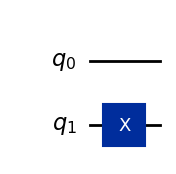

In [9]:
def oracle_f1(qc, x, y):
    """
    f1(x) = 1  (constant one)
    
    Oracle action: |x⟩|y⟩ → |x⟩|y XOR 1⟩ = |x⟩|NOT y⟩
    """
    
    # f(x) = 1 for all x, so y XOR f(x) = y XOR 1 = NOT y.
    # X gate (Pauli-X) is the quantum NOT — flips |0⟩↔|1⟩ unconditionally.
    # No dependency on x: the flip happens regardless of the input qubit's state.
    qc.x(y)
    # Return the resulting qc
    return qc

# Display the circuit for oracle_f1
# Expected: a single X gate on the ancilla qubit y — no dependency on x
display(oracle_f1(QuantumCircuit(2), 0, 1).draw('mpl'))

### **oracle_f2(qc, x, y) - identity / balanced function:**

``oracle_f2`` implements the identity function ``f(x) = x``. Since ``f(x) = x``, the oracle transformation becomes:

$$U_{f_2}\,|x\rangle|y\rangle = |x\rangle|y \oplus x\rangle$$
 
The ancilla qubit y is flipped if and only if x = 1, and left unchanged if x = 0. This is implemented with a single CNOT gate, where x is the control qubit and y is the target. The CNOT is the natural quantum gate for this operation: it applies a Pauli-X to the target only when the control is |1⟩, which is exactly the behaviour y ⊕ x requires. Unlike ``oracle_f1`` which flips y unconditionally, and ``oracle_f3`` which flips y when x = 0, ``oracle_f2`` flips y when x = 1 — making it the most direct mapping from a classical Boolean function to a quantum gate, as the function value and the control condition are one and the same.

* **Step 1:** Receive the quantum circuit qc and qubit indices x (input/control) and y (ancilla/target).
* **Step 2:** Apply a CNOT gate with x as the control and y as the target to implement y⊕x.
* **Step 3:** Return the modified circuit.

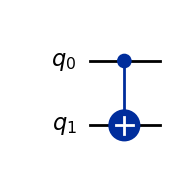

In [10]:
def oracle_f2(qc, x, y):
    """
    f2(x) = x  (identity / balanced)
    
    Oracle action: |x⟩|y⟩ → |x⟩|y XOR x⟩
    """
    
    # f(x) = x, so y XOR f(x) = y XOR x — flip y iff x is |1⟩.
    # CNOT (controlled-X): x is the control qubit, y is the target.
    # |0⟩|y⟩ → |0⟩|y⟩  (x=0: no flip)
    # |1⟩|y⟩ → |1⟩|NOT y⟩  (x=1: flip y)
    qc.cx(x, y)

    # Return the resulting qc
    return qc

# Display the circuit for oracle_f2
# Expected: a single CNOT gate with x as control and y as target
display(oracle_f2(QuantumCircuit(2), 0, 1).draw('mpl'))

### **oracle_f3(qc, x, y) - negation / balanced function:**

``oracle_f3`` implements the negation function ``f(x) = NOT x``. Since ``f(x) = NOT x``, the oracle transformation becomes:

$$U_{f_3}\,|x\rangle|y\rangle = |x\rangle|y \oplus 1 \oplus x\rangle$$

Since x⊕1=¬x, this simplifies to:

$$U_{f_3}\,|x\rangle|y\rangle = |x\rangle|y \oplus \neg x\rangle$$

The ancilla qubit y is first entangled with the input qubit x using a CNOT gate, which flips y when x=1. An X gate is then applied to y, which flips the result unconditionally. Together, these operations implement the required conditional behaviour for the negation function.

* **Step 1:** Receive the quantum circuit qc and qubit indices x (input) and y (ancilla/target).
* **Step 2:** Apply a CNOT gate with x as control and y as target to compute y⊕x.
* **Step 3:** Apply an X gate to y, producing y⊕x⊕1=y⊕¬x.
* **Step 4:** Return the modified circuit.

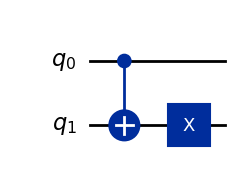

In [11]:
def oracle_f3(qc, x, y):
    """
    f(x) = NOT x implemented using CX then X on y.

    Oracle action:
    |x⟩|y⟩ → |x⟩|y ⊕ x ⊕ 1⟩ → |x⟩|y ⊕ ¬x⟩
    """

    # Step 1: Entangle input with output (standard CNOT)
    qc.cx(x, y)

    # Step 2: Flip output to complete ¬x transformation
    qc.x(y)

    # Step 3: Return circuit
    return qc

# Display the circuit for oracle_f3
# Expected: X gate on x, then CNOT(x → y), then X gate on x to restore x
display(oracle_f3(QuantumCircuit(2), 0, 1).draw('mpl'))

### **Problem 3 Testing**

**Main function which automates tests**

In [12]:
def run_oracle(oracle_fn, x_init: int, y_init: int) -> tuple[int, int]:
    """
    Build a two-qubit circuit, initialise |x⟩|y⟩ to the given basis state,
    apply the oracle, measure both qubits, and return (x_measured, y_measured).
 
    Because the inputs are computational basis states (no superposition), the
    result is deterministic — 1024 shots all produce the same bitstring.
 
    Qiskit's measurement string is ordered q1q0 (most-significant bit first),
    so we reverse it before extracting individual qubit values.
    """
    qr = QuantumRegister(2, 'q')
    cr = ClassicalRegister(2, 'c')
    qc = QuantumCircuit(qr, cr)
 
    # Initialise input qubit x (qr[0]) to |x_init⟩
    if x_init == 1:
        qc.x(qr[0])
 
    # Initialise ancilla qubit y (qr[1]) to |y_init⟩
    if y_init == 1:
        qc.x(qr[1])
 
    # Apply the oracle under test
    oracle_fn(qc, qr[0], qr[1])
 
    # Measure both qubits
    qc.measure(qr, cr)
 
    # Simulate and extract the single deterministic outcome
    simulator = AerSimulator()
    result = simulator.run(qc, shots=1024).result()
    counts = result.get_counts()
 
    # counts keys are bitstrings ordered "c1c0"; reverse to get [c0, c1]
    bitstring = max(counts, key=counts.get)[::-1]
    x_out = int(bitstring[0])   # qubit 0 — the input qubit x
    y_out = int(bitstring[1])   # qubit 1 — the ancilla qubit y
 
    return x_out, y_out

#### **oracle_f0 Function Tests:**

In [13]:
# Tests oracle_f0 with 00 input 
def test_f0_input_00():
    # f0 is the constant zero function, so f0(0) = 0.
    # The oracle computes y XOR f0(x) = 0 XOR 0 = 0, so y is unchanged.
    # Since f0 never depends on x, x is also unchanged — both qubits stay 0.
    x_out, y_out = run_oracle(oracle_f0, x_init=0, y_init=0)
    assert x_out == 0 and y_out == 0  # |0⟩|0⟩ → |0⟩|0⟩  (0 XOR 0 = 0)
    print(f"f0 |0⟩|0⟩ → |{x_out}⟩|{y_out}⟩ ✓")
 
# Tests oracle_f0 with 01 input 
def test_f0_input_01():
    # f0 is the constant zero function, so f0(1) = 0.
    # The oracle computes y XOR f0(x) = 0 XOR 0 = 0, so y is unchanged.
    # This confirms that even when x = 1, f0 still returns 0 — it is constant.
    x_out, y_out = run_oracle(oracle_f0, x_init=0, y_init=1)
    assert x_out == 0 and y_out == 1  # |0⟩|1⟩ → |0⟩|1⟩  (1 XOR 0 = 1)
    print(f"f0 |0⟩|1⟩ → |{x_out}⟩|{y_out}⟩ ✓")
 
# Tests oracle_f0 with 10 input 
def test_f0_input_10():
    # f0 is the constant zero function, so f0(1) = 0.
    # The oracle computes y XOR f0(x) = 0 XOR 0 = 0, so y is unchanged.
    # This confirms that even when x = 1, f0 still returns 0 — it is constant.
    x_out, y_out = run_oracle(oracle_f0, x_init=1, y_init=0)
    assert x_out == 1 and y_out == 0  # |1⟩|0⟩ → |1⟩|0⟩  (0 XOR 0 = 0)
    print(f"f0 |1⟩|0⟩ → |{x_out}⟩|{y_out}⟩ ✓")
 
# Tests oracle_f0 with 11 input 
def test_f0_input_11():
    # f0 is the constant zero function, so f0(1) = 0.
    # The oracle computes y XOR f0(x) = 1 XOR 0 = 1, so y remains 1.
    # Together, all four tests confirm that oracle_f0 leaves every input
    # unchanged — consistent with XOR-ing by 0 being the identity operation.
    x_out, y_out = run_oracle(oracle_f0, x_init=1, y_init=1)
    assert x_out == 1 and y_out == 1  # |1⟩|1⟩ → |1⟩|1⟩  (1 XOR 0 = 1)
    print(f"f0 |1⟩|1⟩ → |{x_out}⟩|{y_out}⟩ ✓")

#### **oracle_f1 Function Tests:**

In [14]:
# Tests oracle_f1 with 00 input 
def test_f1_input_00():
    # f1 is the constant one function, so f1(0) = 1.
    # The oracle computes y XOR f1(x) = 0 XOR 1 = 1, so y flips from 0 to 1.
    # x is unaffected — the X gate in oracle_f1 acts only on the ancilla qubit.
    x_out, y_out = run_oracle(oracle_f1, x_init=0, y_init=0)
    assert x_out == 0 and y_out == 1  # |0⟩|0⟩ → |0⟩|1⟩  (0 XOR 1 = 1)
    print(f"f1 |0⟩|0⟩ → |{x_out}⟩|{y_out}⟩ ✓")

# Tests oracle_f1 with 01 input 
def test_f1_input_01():
    # f1 is the constant one function, so f1(0) = 1.
    # The oracle computes y XOR f1(x) = 1 XOR 1 = 0, so y flips from 1 to 0.
    # This shows the X gate always toggles y — when y starts as 1, it becomes 0.
    x_out, y_out = run_oracle(oracle_f1, x_init=0, y_init=1)
    assert x_out == 0 and y_out == 0  # |0⟩|1⟩ → |0⟩|0⟩  (1 XOR 1 = 0)
    print(f"f1 |0⟩|1⟩ → |{x_out}⟩|{y_out}⟩ ✓")
 
# Tests oracle_f1 with 10 input 
def test_f1_input_10():
    # f1 is the constant one function, so f1(1) = 1.
    # The oracle computes y XOR f1(x) = 0 XOR 1 = 1, so y flips from 0 to 1.
    # Critically, x = 1 here — confirming the flip still occurs regardless of x.
    x_out, y_out = run_oracle(oracle_f1, x_init=1, y_init=0)
    assert x_out == 1 and y_out == 1  # |1⟩|0⟩ → |1⟩|1⟩  (0 XOR 1 = 1)
    print(f"f1 |1⟩|0⟩ → |{x_out}⟩|{y_out}⟩ ✓")
 
# Tests oracle_f1 with 11 input 
def test_f1_input_11():
    # f1 is the constant one function, so f1(1) = 1.
    # The oracle computes y XOR f1(x) = 1 XOR 1 = 0, so y flips from 1 to 0.
    # All four tests together confirm that oracle_f1 always flips y regardless
    # of x — consistent with the unconditional X gate used in its implementation.
    x_out, y_out = run_oracle(oracle_f1, x_init=1, y_init=1)
    assert x_out == 1 and y_out == 0  # |1⟩|1⟩ → |1⟩|0⟩  (1 XOR 1 = 0)
    print(f"f1 |1⟩|1⟩ → |{x_out}⟩|{y_out}⟩ ✓")

#### **oracle_f2 Function Tests:**

In [15]:
# Tests oracle_f2 with 00 input
def test_f2_input_00():
    # f2 is the identity function, so f2(0) = 0.
    # The oracle computes y XOR f2(x) = 0 XOR 0 = 0, so y remains 0.
    # Since x = 0, the CNOT in oracle_f2 does not fire — its control qubit is 0,
    # so the target qubit y is left completely unchanged. Neither qubit changes.
    x_out, y_out = run_oracle(oracle_f2, x_init=0, y_init=0)
    assert x_out == 0 and y_out == 0  # |0⟩|0⟩ → |0⟩|0⟩  (0 XOR 0 = 0)
    print(f"f2 |0⟩|0⟩ → |{x_out}⟩|{y_out}⟩ ✓")
 
# Tests oracle_f2 with 01 input
def test_f2_input_01():
    # f2 is the identity function, so f2(0) = 0.
    # The oracle computes y XOR f2(x) = 1 XOR 0 = 1, so y remains 1.
    # Again x = 0, so the CNOT does not fire — y is left at its initial value of 1.
    # This confirms that when x = 0, oracle_f2 behaves as the identity regardless
    # of y's starting value, consistent with f2(0) = 0 contributing nothing to XOR.
    x_out, y_out = run_oracle(oracle_f2, x_init=0, y_init=1)
    assert x_out == 0 and y_out == 1  # |0⟩|1⟩ → |0⟩|1⟩  (1 XOR 0 = 1)
    print(f"f2 |0⟩|1⟩ → |{x_out}⟩|{y_out}⟩ ✓")

# Tests oracle_f2 with 10 input
def test_f2_input_10():
    # f2 is the identity function, so f2(1) = 1.
    # The oracle computes y XOR f2(x) = 0 XOR 1 = 1, so y flips from 0 to 1.
    # Since x = 1, the CNOT fires — its control qubit is 1, so the target qubit
    # y is flipped. This is the key case that distinguishes oracle_f2 from oracle_f0:
    # the oracle only modifies y when x = 1, directly encoding the identity function.
    x_out, y_out = run_oracle(oracle_f2, x_init=1, y_init=0)
    assert x_out == 1 and y_out == 1  # |1⟩|0⟩ → |1⟩|1⟩  (0 XOR 1 = 1)
    print(f"f2 |1⟩|0⟩ → |{x_out}⟩|{y_out}⟩ ✓")

# Tests oracle_f2 with 11 input
def test_f2_input_11():
    # f2 is the identity function, so f2(1) = 1.
    # The oracle computes y XOR f2(x) = 1 XOR 1 = 0, so y flips from 1 to 0.
    # x = 1 again, so the CNOT fires and toggles y — when y starts as 1 it becomes 0.
    # All four tests together confirm that oracle_f2 flips y if and only if x = 1,
    # which is exactly the behaviour of a CNOT gate and the identity function f2(x) = x.
    x_out, y_out = run_oracle(oracle_f2, x_init=1, y_init=1)
    assert x_out == 1 and y_out == 0  # |1⟩|1⟩ → |1⟩|0⟩  (1 XOR 1 = 0)
    print(f"f2 |1⟩|1⟩ → |{x_out}⟩|{y_out}⟩ ✓")

#### **oracle_f3 Function Tests:**

In [16]:
# Tests oracle_f3 with 00 input
def test_f3_input_00():
    # f3 is the negation function, so f3(0) = NOT 0 = 1.
    # The oracle computes y XOR f3(x) = 0 XOR 1 = 1, so y flips from 0 to 1.
    # Since x = 0, the first X gate in oracle_f3 temporarily flips x to 1,
    # causing the CNOT to fire and flip y. The second X gate then restores x to 0.
    # This is the anti-controlled NOT in action — the flip occurs because x = 0,
    # which is the opposite control condition to oracle_f2's CNOT.
    x_out, y_out = run_oracle(oracle_f3, x_init=0, y_init=0)
    assert x_out == 0 and y_out == 1  # |0⟩|0⟩ → |0⟩|1⟩  (0 XOR NOT 0 = 1)
    print(f"f3 |0⟩|0⟩ → |{x_out}⟩|{y_out}⟩ ✓")
 
# Tests oracle_f3 with 01 input
def test_f3_input_01():
    # f3 is the negation function, so f3(0) = NOT 0 = 1.
    # The oracle computes y XOR f3(x) = 1 XOR 1 = 0, so y flips from 1 to 0.
    # Again x = 0, so the flanking X gates cause the CNOT to fire, toggling y.
    # When y starts as 1 it becomes 0 — confirming the flip always occurs when
    # x = 0, regardless of y's initial value.
    x_out, y_out = run_oracle(oracle_f3, x_init=0, y_init=1)
    assert x_out == 0 and y_out == 0  # |0⟩|1⟩ → |0⟩|0⟩  (1 XOR NOT 0 = 0)
    print(f"f3 |0⟩|1⟩ → |{x_out}⟩|{y_out}⟩ ✓")
 
# Tests oracle_f3 with 10 input
def test_f3_input_10():
    # f3 is the negation function, so f3(0) = NOT 0 = 1.
    # The oracle computes y XOR f3(x) = 1 XOR 1 = 0, so y flips from 1 to 0.
    # Again x = 0, so the flanking X gates cause the CNOT to fire, toggling y.
    # When y starts as 1 it becomes 0 — confirming the flip always occurs when
    # x = 0, regardless of y's initial value.
    x_out, y_out = run_oracle(oracle_f3, x_init=1, y_init=0)
    assert x_out == 1 and y_out == 0  # |1⟩|0⟩ → |1⟩|0⟩  (0 XOR NOT 1 = 0)
    print(f"f3 |1⟩|0⟩ → |{x_out}⟩|{y_out}⟩ ✓")

# Tests oracle_f3 with 11 input
def test_f3_input_11():
    # f3 is the negation function, so f3(1) = NOT 1 = 0.
    # The oracle computes y XOR f3(x) = 0 XOR 0 = 0, so y remains unchanged.
    # Since x = 1, the first X gate flips x to 0, so the CNOT does not fire —
    # its control is now 0 after the flip. The second X gate restores x to 1.
    # This is the key case that distinguishes oracle_f3 from oracle_f1: when
    # x = 1, no flip occurs, because f3(1) = 0 contributes nothing to the XOR.
    x_out, y_out = run_oracle(oracle_f3, x_init=1, y_init=1)
    assert x_out == 1 and y_out == 1  # |1⟩|1⟩ → |1⟩|1⟩  (1 XOR NOT 1 = 1)
    print(f"f3 |1⟩|1⟩ → |{x_out}⟩|{y_out}⟩ ✓")

#### Run the tests from main

In [17]:
# Main function to run the tests for the oracles
if __name__ == "__main__":
    # Run tests for oracle_f0
    print("oracle_f0 tests:")
    test_f0_input_00()
    test_f0_input_01()
    test_f0_input_10()
    test_f0_input_11()
    
    # Run tests for oracle_f1
    print("\noracle_f1 tests:")
    test_f1_input_00()
    test_f1_input_01()
    test_f1_input_10()
    test_f1_input_11()

    # Run tests for oracle_f2
    print("\noracle_f2 tests:")
    test_f2_input_00()
    test_f2_input_01()
    test_f2_input_10()
    test_f2_input_11()
    
    # Run tests for oracle_f3
    print("\noracle_f3 tests:")
    test_f3_input_00()
    test_f3_input_01()
    test_f3_input_10()
    test_f3_input_11()

oracle_f0 tests:
f0 |0⟩|0⟩ → |0⟩|0⟩ ✓
f0 |0⟩|1⟩ → |0⟩|1⟩ ✓
f0 |1⟩|0⟩ → |1⟩|0⟩ ✓
f0 |1⟩|1⟩ → |1⟩|1⟩ ✓

oracle_f1 tests:
f1 |0⟩|0⟩ → |0⟩|1⟩ ✓
f1 |0⟩|1⟩ → |0⟩|0⟩ ✓
f1 |1⟩|0⟩ → |1⟩|1⟩ ✓
f1 |1⟩|1⟩ → |1⟩|0⟩ ✓

oracle_f2 tests:
f2 |0⟩|0⟩ → |0⟩|0⟩ ✓
f2 |0⟩|1⟩ → |0⟩|1⟩ ✓
f2 |1⟩|0⟩ → |1⟩|1⟩ ✓
f2 |1⟩|1⟩ → |1⟩|0⟩ ✓

oracle_f3 tests:
f3 |0⟩|0⟩ → |0⟩|1⟩ ✓
f3 |0⟩|1⟩ → |0⟩|0⟩ ✓
f3 |1⟩|0⟩ → |1⟩|0⟩ ✓
f3 |1⟩|1⟩ → |1⟩|1⟩ ✓


## **Problem 4: Deutsch's Algorithm with Qiskit**

### **Introduction**

In **Problem 3** the quantum oracles were built: circuits that encode each of the four single-input Boolean functions in a way a quantum circuit can exploit. Now we assemble those oracles into a complete implementation of [Deutsch's algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm): the circuit that determines whether a function is constant (``f(0) = f(1)``) or balanced (``f(0) ≠ f(1)``) using only a **single query** to the oracle.

Deutsch's algorithm was one of the first demonstrations that a quantum computer can outperform a classical one on a well-defined problem. Classically, as established in **Problem 2**, you need **2 queries** to be certain. Deutsch's algorithm needs only **1**.

### **Function build_deutsch_circuit(oracle_fn):**

The ``build_deutsch_circuit`` function constructs the quantum circuit for Deutsch's algorithm for a given oracle.

The circuit uses two qubits, referred to throughout this problem as:

- **q0** — the input qubit $|x\rangle$, initialised to $|0\rangle$
- **q1** — the ancilla qubit $|y\rangle$, initialised to $|1\rangle$

The algorithm proceeds in four steps:

**Step 1 — Initialise the ancilla.**
An [X gate](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.XGate) is applied to q1, flipping it from $|0\rangle$ to $|1\rangle$. This is a required setup step — without it, the phase kickback mechanism (explained below) cannot function. 

**Step 2 — Apply Hadamard gates to both qubits.**
A [Hadamard gate](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.HGate) puts a qubit into an equal superposition of $|0\rangle$ and $|1\rangle$:

$$|0\rangle \xrightarrow{H} |{+}\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}$$
$$|1\rangle \xrightarrow{H} |{-}\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}$$

After this step:
- q0 is in the $|{+}\rangle$ state — a superposition that allows the oracle to evaluate $f(0)$ and $f(1)$ simultaneously.
- q1 is in the $|{-}\rangle$ state — the special ancilla state that enables phase kickback.

**Step 3 — Query the oracle ([phase kickback](https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/quantum-query-algorithms)).**
When q1 is in the $|{-}\rangle$ state, the oracle does something remarkable. Instead of writing the result into the ancilla, it encodes the function's output as a **global phase** on the input qubit:

$$U_f\,|x\rangle|{-}\rangle = (-1)^{f(x)}\,|x\rangle|{-}\rangle$$

The ancilla is left unchanged — the phase $(-1)^{f(x)}$ is "kicked back" onto q0. Since q0 is in superposition over both $x=0$ and $x=1$, the full state after the oracle is:

$$\frac{(-1)^{f(0)}|0\rangle + (-1)^{f(1)}|1\rangle}{\sqrt{2}} \otimes |{-}\rangle$$

**Step 4 — Apply a Hadamard to q0 and measure.**
The second Hadamard on q0 converts the phase difference into a measurable amplitude difference through [interference](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-jozsa-algorithm):

- **Constant function** ($f(0) = f(1)$): Both terms carry the same phase, so they interfere **constructively** at $|0\rangle$ and **destructively** at $|1\rangle$. Measuring q0 always gives $|0\rangle$.
- **Balanced function** ($f(0) \neq f(1)$): The terms carry opposite phases, so they interfere **destructively** at $|0\rangle$ and **constructively** at $|1\rangle$. Measuring q0 always gives $|1\rangle$.

| Measurement outcome | Classification |
|:---:|:---:|
| q0 = 0 | Constant |
| q0 = 1 | Balanced |

In [18]:
def build_deutsch_circuit(oracle_fn):
  """
  Construct the Deutsch algorithm circuit for a given oracle.
 
  The circuit uses two qubits:
    q0 — input qubit (x): initialised to |0⟩
    q1 — ancilla qubit (y): initialised to |1⟩ via an X gate
 
  Returns the full circuit before measurement so the state can be inspected.
  """

  qr = QuantumRegister(2, 'q')
  cr = ClassicalRegister(1, 'c')
  qc = QuantumCircuit(qr, cr)

  # Initialise ancilla to |1⟩ — required for phase kickback to work
  # Without this, the oracle XORs into |0⟩ and no phase is imprinted
  qc.x(qr[1])
 
  # Apply Hadamard to both qubits
  # q0: |0⟩ → |+⟩ = (|0⟩ + |1⟩)/√2  — superposition over both inputs
  qc.h(qr[0])
  # q1: |1⟩ → |−⟩ = (|0⟩ − |1⟩)/√2  — the phase kickback ancilla state
  qc.h(qr[1])
 
    # visually separate initialisation from oracle
  qc.barrier()  
 
  # Apply the oracle. With q1 in |−⟩, the oracle imprints a phase:
  #   |x⟩|−⟩ → (−1)^f(x) |x⟩|−⟩
  # The ancilla is unchanged; the phase is now on q0.
  oracle_fn(qc, qr[0], qr[1])
 
  # visually separate oracle from interference step
  qc.barrier() 
 
  # Apply Hadamard to q0 only to interfere the two phase-encoded amplitudes
  # Constant f:  phases equal    → constructive interference → |0⟩
  # Balanced f:  phases opposite → destructive interference  → |1⟩
  qc.h(qr[0])
 
  # Measure only q0 — it encodes the constant/balanced answer
  qc.measure(qr[0], cr[0])
 
  return qc

### **Function run_deutsch(oracle_fn):**

The ``run_deutsch`` function executes the Deutsch circuit for a given oracle and maps the measurement outcome to a classification. 

It calls ``build_deutsch_circuit`` to construct the circuit, then simulates it using [Qiskit's AerSimulator](https://qiskit.github.io/qiskit-aer/#) over 1024 shots. 

Because the result is deterministic — the interference pattern always collapses q0 to either |0⟩ or |1⟩ with certainty — all 1024 shots produce the same bitstring, and the shot count affects only statistical confidence rather than correctness. The dominant measurement outcome is extracted from the counts and mapped directly to a classification: a measured bit of '0' means the function is constant, since constructive interference concentrated all amplitude on |0⟩, and a measured bit of '1' means the function is balanced, since destructive interference redirected all amplitude away from |0⟩. The function returns the classification, the raw counts, and the circuit itself so the result can be inspected and verified by the caller.

In [19]:
def run_deutsch(oracle_fn): 
    """
    Run the Deutsch circuit for the given oracle and return the classification
    ('CONSTANT' or 'BALANCED') along with the raw measurement counts.
    """

    # Create quantum circuit 
    qc = build_deutsch_circuit(oracle_fn)

    # Simulate with 1024 shots. The result is deterministic — all shots produce
    # the same bit — so shot count only affects statistical confidence.
    counts = AerSimulator().run(qc, shots=1024).result().get_counts()
 
    # q0 = '0' → constant, q0 = '1' → balanced
    measured_bit = max(counts, key=counts.get)
    classification = "CONSTANT" if measured_bit == '0' else "BALANCED"
 
    return classification, counts, qc
 

### **Problem 4 Testing**

The cell below runs Deutsch's algorithm with each of the four oracles from Problem 3 and prints the circuit, measurement counts, and classification for each. The result should always agree with the known type of each function.

Oracle : f0: constant zero
Expected     : CONSTANT
Classified as: CONSTANT
Counts       : {'0': 1024}
Result       : PASS


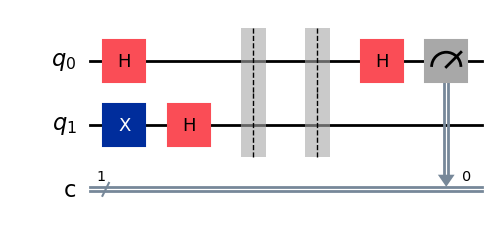


Oracle : f1: constant one
Expected     : CONSTANT
Classified as: CONSTANT
Counts       : {'0': 1024}
Result       : PASS


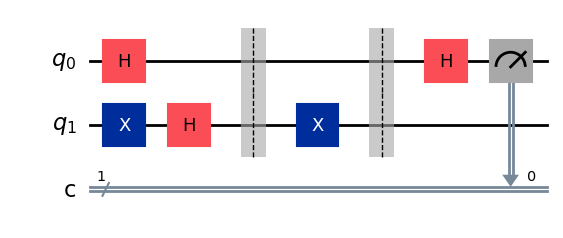


Oracle : f2: identity
Expected     : BALANCED
Classified as: BALANCED
Counts       : {'1': 1024}
Result       : PASS


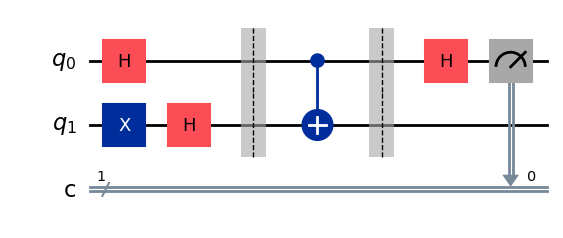


Oracle : f3: negation
Expected     : BALANCED
Classified as: BALANCED
Counts       : {'1': 1024}
Result       : PASS


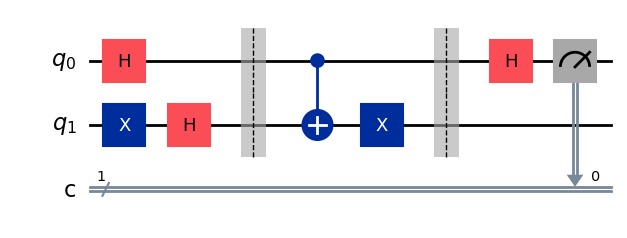

In [20]:
# List of oracle functions with:
# (1) function implementation
# (2) human-readable label
# (3) expected classification from Deutsch's algorithm
oracles = [
    (oracle_f0, "f0: constant zero",     "CONSTANT"),
    (oracle_f1, "f1: constant one",      "CONSTANT"),
    (oracle_f2, "f2: identity",          "BALANCED"),
    (oracle_f3, "f3: negation",          "BALANCED"),
]

# Iterate over each oracle and test it using Deutsch's algorithm
for oracle_fn, label, expected in oracles:

    # Run Deutsch's algorithm using the selected oracle function
    # This returns:
    # - classification: result of the algorithm ("CONSTANT" or "BALANCED")
    # - counts: measurement statistics from the quantum circuit
    # - qc: the full quantum circuit used in the execution
    classification, counts, qc = run_deutsch(oracle_fn)

    # Print a formatted separator for readability between tests
    print("=" * 45)

    # Display which oracle is currently being tested
    print(f"Oracle : {label}")

    # Show the theoretically correct classification
    print(f"Expected     : {expected}")

    # Show the classification returned by the quantum algorithm
    print(f"Classified as: {classification}")

    # Show raw measurement results from the quantum circuit
    print(f"Counts       : {counts}")

    # Compare expected vs actual result and report success/failure
    print(f"Result       : {'PASS' if classification == expected else 'FAIL'}")

    # End separator for clarity
    print("=" * 45)

    # Visualize the full quantum circuit used for this oracle test
    # This includes state preparation, oracle application, and measurement
    display(qc.draw('mpl'))

    # Print blank line for spacing between circuit outputs
    print()

## **Problem 5: Scaling to the Deutsch–Jozsa Algorithm**


### **Introduction:** 

In **Problem 4** Deutsch's algorithm was implemented for functions with a **single Boolean input** — the simplest possible case. **Problem 5** generalises this to functions with
**four Boolean inputs**, as generated by `random_constant_balanced()` in **Problem 1**.

This is the full [Deutsch–Jozsa algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-jozsa-algorithm).

The core ideas are identical to **Problem 4** — superposition, phase kickback, and interference. The difference is scale: instead of 1 input qubit, we now have 4, giving 2⁴ = 16 possible input combinations. The quantum circuit still solves the problem in a **single query**, while the classical solution established in Problem 2 requires up to **9 queries** in the worst case.

**How the Algorithm Scales from Problem 4**

The Deutsch circuit from Problem 4 had the following structure:

$$|0\rangle \xrightarrow{H} \text{Oracle} \xrightarrow{H} \text{Measure}$$

The Deutsch–Jozsa circuit is a direct generalisation — every step is the same, just applied to 4 input qubits instead of 1:

$$|0\rangle^{\otimes 4} \xrightarrow{H^{\otimes 4}} \text{Oracle} \xrightarrow{H^{\otimes 4}} \text{Measure}$$

The ancilla qubit q4 is initialised and handled identically to Problem 4 — flipped to $|1\rangle$ with an [X gate](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.XGate), then put into the $|{-}\rangle$ state with a [Hadamard gate](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.HGate)
to enable [phase kickback](https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/quantum-query-algorithms).

| | Deutsch (Problem 4) | Deutsch–Jozsa (Problem 5) |
|:---|:---:|:---:|
| Input qubits | 1 | 4 |
| Ancilla qubits | 1 | 1 |
| Total qubits | 2 | 5 |
| Possible inputs | 2 | 16 |
| Queries needed | 1 | 1 |
| Classical worst case | 2 | 9 |

### **build_oracle(classical_fn)**

The ``build_oracle(classical_fn)`` function essentially encapsulates step 1 of the Deutsch-Josza algorithm: encoding the classical function as a quantum oracle

In **Problem 3**, each oracle was hand-crafted for a specific known function. Here, the oracle must be constructed automatically from any classical function produced by `random_constant_balanced()` — we do not know in advance which inputs return `True`.

The approach uses the same pattern** introduced in Problem 3 for `oracle_f3`, but generalised to 4 control qubits using a [multi-controlled X gate (MCX)](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.XGate). For each input combination $x$ where $f(x) =$ True, the oracle:

1. **Flips any qubits that are `False` in $x$** using X gates — this temporarily transforms the input register so that the MCX fires on the correct basis state.
2. **Applies an MCX gate** — flips the ancilla q4 if and only if q0–q3 all hold $|1\rangle$, encoding $y \oplus f(x)$ via phase kickback.
3. **Restores the flipped qubits** with another round of X gates — leaving the input register unchanged, as required by unitarity.

This is repeated for every input where $f(x) =$ True. The result is a circuit that encodes the full truth table of $f$ into quantum phases, consistent with the oracle construction described in the [IBM Quantum Learning documentation](https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/quantum-query-algorithms).

In [ ]:
"""
Problem 5: Scaling to the Deutsch-Jozsa Algorithm (4-bit)
==========================================================
Generalises Deutsch's algorithm (Problem 4) to f: {0,1}^4 → {0,1}.

Builds directly on:
  - Problem 1: random_constant_balanced() generates the functions under test
  - Problem 2: determine_constant_balanced() provides the classical answer to
               verify against and illustrate the classical vs quantum cost
  - Problem 3: same phase kickback oracle construction, scaled to 4 input qubits
  - Problem 4: same H-oracle-H circuit structure, scaled to 4 input qubits

The circuit measures all zeros on q0-q3 if and only if the function is constant.
"""

# ──────────────────────────────────────────────────────────────────────────────
# Step 1 — Encode the classical function as a quantum oracle
# ──────────────────────────────────────────────────────────────────────────────

# All 16 possible 4-bit inputs — used to iterate over the function's truth table
ALL_INPUTS = list(product([False, True], repeat=4))

def build_oracle(classical_fn):
    """
    Convert a classical 4-input Boolean function (from Problem 1) into a
    quantum oracle using the same phase kickback pattern as Problem 3.

    For each input x where f(x) = True, a multi-controlled X gate (MCX) is
    applied to the ancilla qubit, conditioned on the input register holding x.
    X gates flanking the MCX invert any False-bits in x so the MCX fires on
    exactly the right computational basis state — the same X-CNOT-X pattern
    used in oracle_f3 in Problem 3, generalised to 4 control qubits.
    """
    n = 4
    qr = QuantumRegister(n + 1, 'q')  # q0-q3: input qubits, q4: ancilla
    qc = QuantumCircuit(qr)

    for x in ALL_INPUTS:
        if classical_fn(*x):  # only act on inputs where f(x) = True
            # Flip qubits that are False in this input pattern so the MCX
            # fires when the register holds exactly x
            for i, bit in enumerate(x):
                if not bit:
                    qc.x(qr[i])

            # MCX flips ancilla q4 iff q0-q3 match x — encodes y XOR f(x)
            qc.mcx(list(range(n)), n)

            # Restore the input qubits to their original state
            for i, bit in enumerate(x):
                if not bit:
                    qc.x(qr[i])

    return qc

### **build_dj_circuit(classical_fn)**

The ``build_dj_circuit(classical_fn)`` function encapsulates step 2: building the Deutsch–Jozsa circuit.

With the oracle in place, the full Deutsch–Jozsa circuit follows the same ``H–Oracle–H`` structure as Problem 4, scaled to 4 input qubits. The [interference](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-jozsa-algorithm) mechanism is identical — the final layer of [Hadamard gates](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.HGate) converts the phase information encoded by the oracle into a measurable amplitude pattern:

- **Constant function** — all $2^4 = 16$ inputs produce the same phase $(-1)^{f(x)}$. The phases reinforce each other at the all-zeros state $|0000\rangle$, so measuring q0–q3 always gives `0000`.

- **Balanced function** — exactly half the inputs produce phase $+1$ and half produce phase $-1$. These cancel completely at $|0000\rangle$, so the measurement outcome is always a **non-zero** bitstring.

The measurement rule is the same as Problem 4, just extended to 4 bits:

| Measurement outcome | Classification |
|:---:|:---:|
| `0000` | Constant |
| Anything else | Balanced |

This result is described formally in the [IBM Quantum Learning documentation](https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/quantum-query-algorithms) and is simulated here using the [Qiskit AerSimulator](https://docs.quantum.ibm.com/api/qiskit-aer/aer_provider).

**Implementation:**

The circuit follows the same three-stage structure as the Deutsch circuit from Problem 4: 
* First, all qubits are initialised and Hadamarded into superposition
* Second, the oracle is applied
* Third, a final layer of Hadamard gates produces an interference pattern that encodes the answer. The ancilla qubit q4 is initialised to |1⟩ before the Hadamard layer, placing it in the |−⟩ state required for phase kickback — identical to the setup in Problem 4. 
* After the oracle imprints a phase of (−1)^f(x) on each input basis state, the Hadamard gates on q0–q3 interfere those phases: 
    * For a constant function all phases are equal and interfere constructively, concentrating the entire probability amplitude on the all-zeros state |0000⟩
    * For a balanced function the phases cancel at |0000⟩ and the measurement always produces a non-zero bitstring. Only the four input qubits are measured — the ancilla is discarded — and a result of 0000 identifies the function as constant while any other result identifies it as balanced.

In [25]:
# ──────────────────────────────────────────────────────────────────────────────
# Step 2 — Build the Deutsch-Jozsa circuit
# ──────────────────────────────────────────────────────────────────────────────

def build_dj_circuit(classical_fn):
    """
    Build the full Deutsch-Jozsa circuit — a direct generalisation of the
    Deutsch circuit from Problem 4, scaled from 1 to 4 input qubits.

    Problem 4 circuit:    |0⟩ ──H──[oracle]──H── measure
    This circuit:    |0⟩⊗4 ──H⊗4──[oracle]──H⊗4── measure (on q0-q3 only)

    The ancilla qubit q4 is initialised to |1⟩ and Hadamarded into |−⟩ for
    phase kickback, exactly as in Problem 4.
    """
    n = 4
    qr = QuantumRegister(n + 1, 'q')
    cr = ClassicalRegister(n, 'c')
    qc = QuantumCircuit(qr, cr)

    # Initialise ancilla to |1⟩ — same as Problem 4, needed for phase kickback
    qc.x(qr[n])

    # Hadamard on all qubits: input qubits enter uniform superposition,
    # ancilla becomes |−⟩ = (|0⟩ − |1⟩)/√2
    qc.h(qr[:])

    qc.barrier()

    # Apply oracle — imprints (−1)^f(x) phase onto the input register,
    # using the same phase kickback mechanism as Problem 3
    oracle = build_oracle(classical_fn)
    qc.compose(oracle, inplace=True)

    qc.barrier()

    # Hadamard on input qubits only — interferes the phase-encoded amplitudes.
    # Constant f → all phases equal → constructive interference → |0000⟩
    # Balanced f → phases cancel at |0000⟩ → non-zero result
    qc.h(qr[:n])

    # Measure input qubits only — ancilla is discarded
    qc.measure(qr[:n], cr)

    # Return resulting qc
    return qc


### **Runner function - run_dj(classical_fn):** 

The ``run_dj`` function performs step 3 by executing the Deutsch-Jozsa circuit for a given 4-input Boolean function and returns the classification. It calls ``build_dj_circuit`` to construct the circuit, simulates it over 1024 shots, and maps the dominant measurement outcome to either "constant" or "balanced". The result is deterministic — all 1024 shots always agree — so the classification is read directly from whichever bitstring dominates the counts. 
* A measurement of '0000' on q0–q3 indicates a constant function, since constructive interference concentrated all amplitude on the all-zeros state
* Any other outcome indicates a balanced function, since destructive interference prevented any amplitude from reaching '0000'.

In [27]:
def run_dj(classical_fn):
    """
    Run the Deutsch-Jozsa circuit for a function generated by Problem 1.
    Returns the quantum classification, raw counts, and the circuit.
 
    Measurement of '0000' → constant (constructive interference)
    Any other outcome    → balanced (destructive interference at |0000⟩)
    """
    
    # Build the full Deutsch-Jozsa circuit for this function
    qc = build_dj_circuit(classical_fn)
 
    # Simulate using Qiskit's AerSimulator
    # The result is deterministic — all 1024 shots produce the same bitstring for any valid constant or balanced function
    counts = AerSimulator().run(qc, shots=1024).result().get_counts()

    # Extract the most frequent (and for a correct oracle, only) outcome
    outcome = max(counts, key=counts.get)
 
    # Interpret the measurement outcome:
    #   '0000' → all phases reinforced at |0000⟩ → constant
    #   anything else → phases cancelled at |0000⟩ → balanced
    classification = "constant" if all(b == '0' for b in outcome) else "balanced"
 
    # return the quantum classification, raw counts, and the circuit
    return classification, counts, qc

### **Testing**

Function     : Constant False
Classical    : constant
Quantum      : constant
Counts       : {'0000': 1024}
Result       : PASS


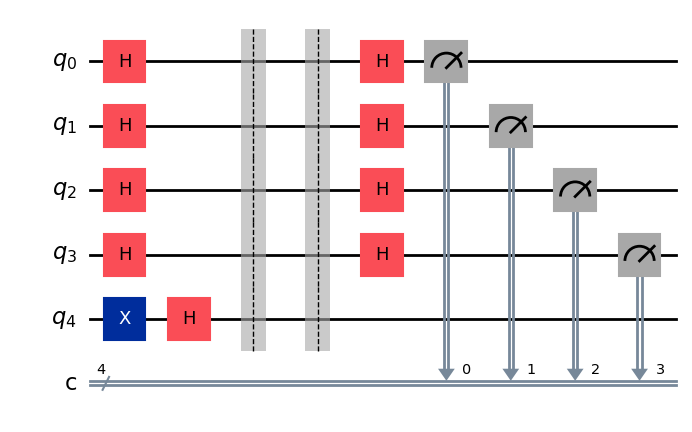


Function     : Constant True
Classical    : constant
Quantum      : constant
Counts       : {'0000': 1024}
Result       : PASS


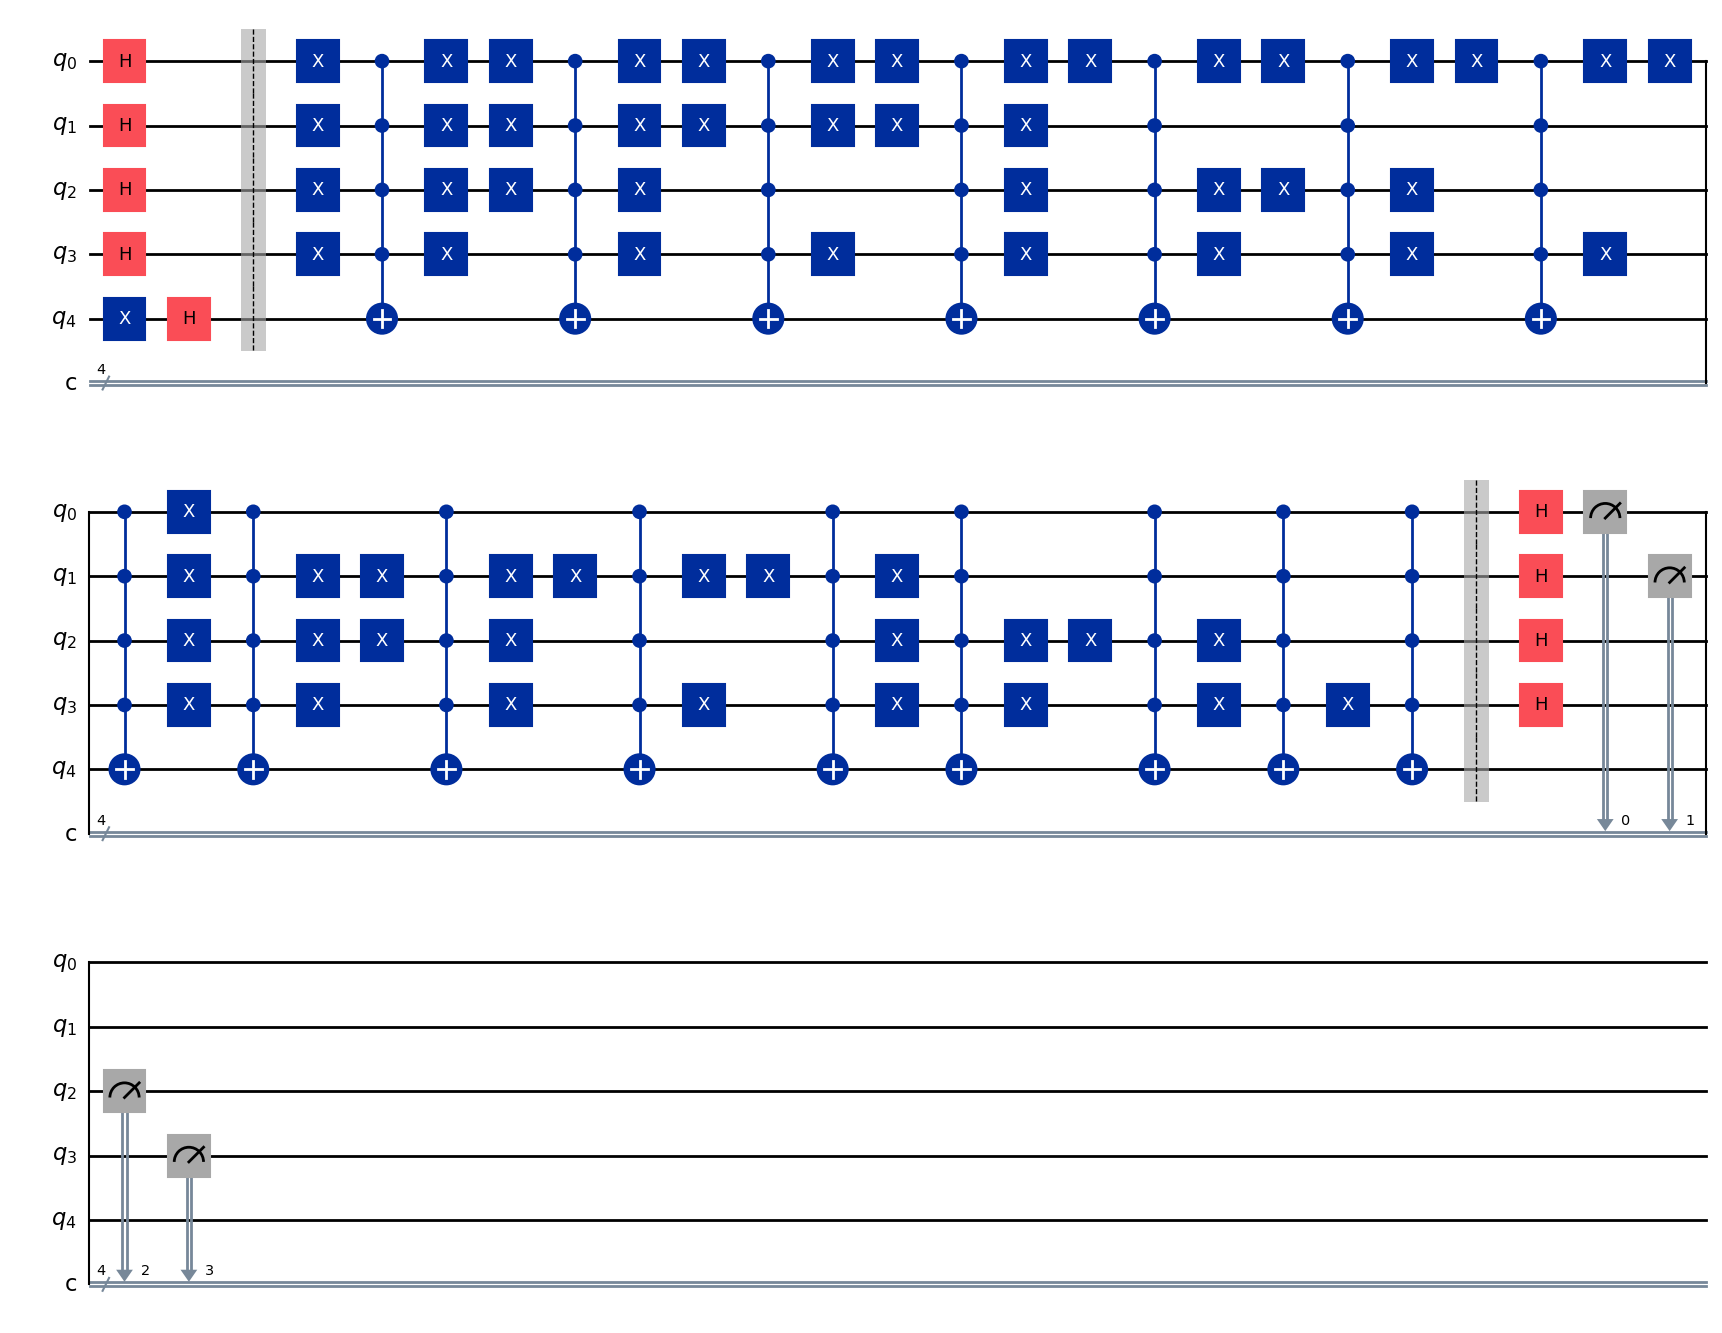


Function     : Balanced function 1
Classical    : balanced
Quantum      : balanced
Counts       : {'0010': 64, '0101': 60, '0110': 57, '0100': 263, '1011': 67, '0011': 246, '1000': 63, '1100': 75, '1111': 69, '0001': 60}
Result       : PASS


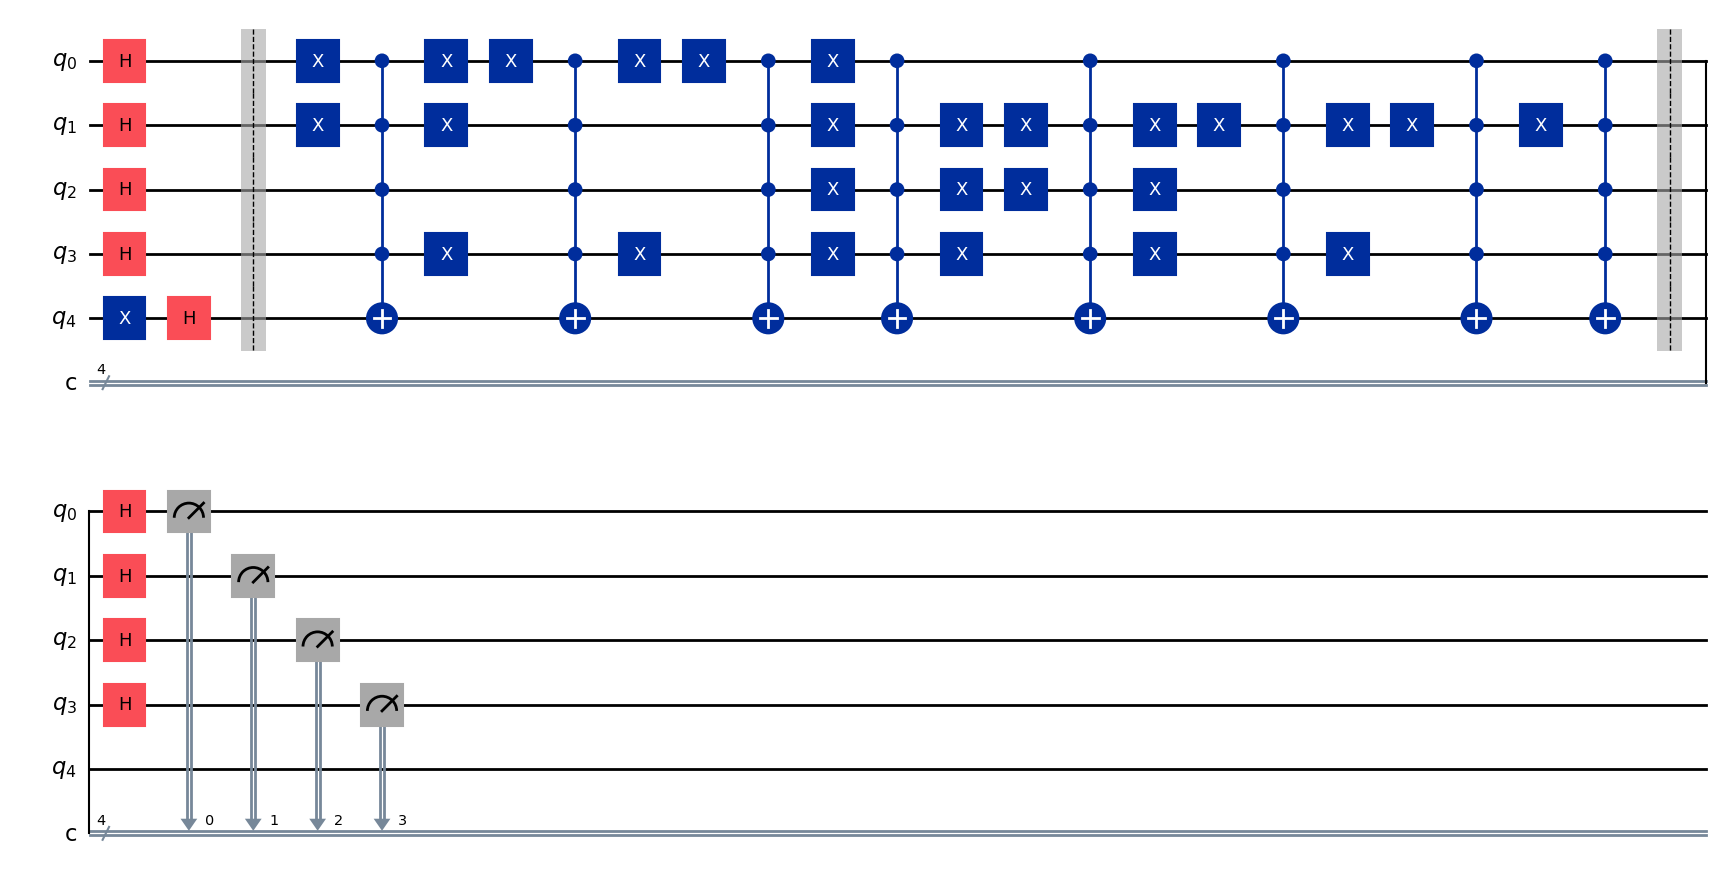


Function     : Balanced function 2
Classical    : balanced
Quantum      : balanced
Counts       : {'1001': 64, '1000': 61, '1111': 60, '0010': 72, '0100': 74, '0011': 575, '1110': 68, '0101': 50}
Result       : PASS


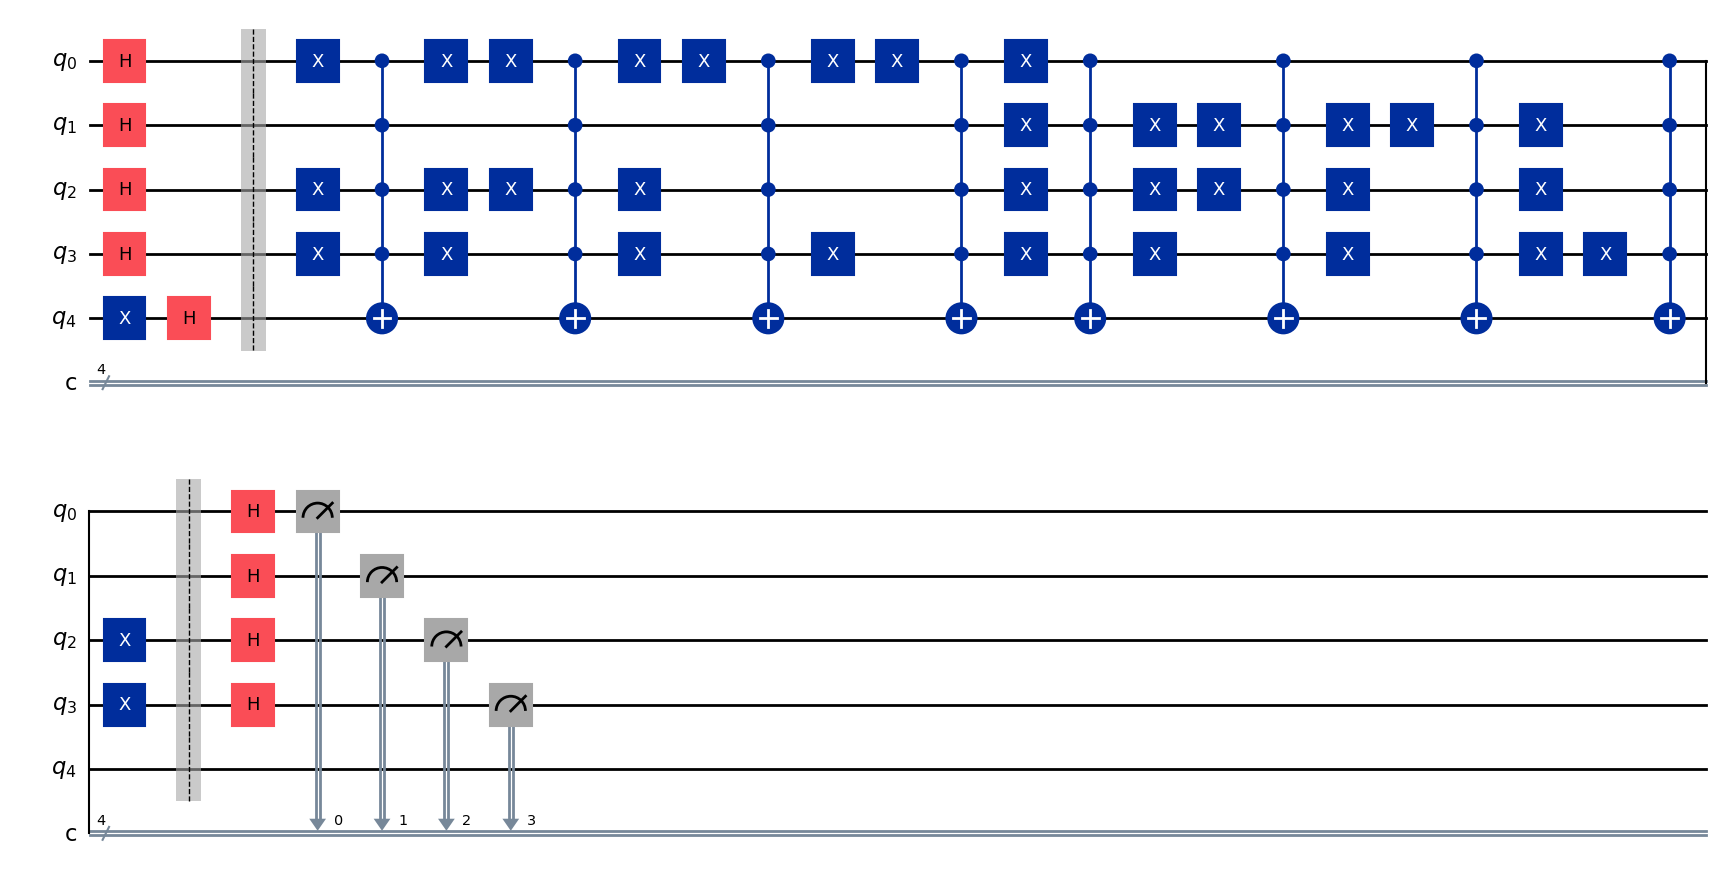

In [28]:
# -------------------------------------------------------------------------
# Define the four test functions:
#   - Constant False: always returns False
#   - Constant True:  always returns True
#   - Two randomly generated balanced functions from Problem 1
# -------------------------------------------------------------------------

constant_false = lambda a, b, c, d: False
constant_true  = lambda a, b, c, d: True

# Generate balanced functions — re-run to get different balanced examples
balanced_f1 = random_constant_balanced()
while determine_constant_balanced(balanced_f1) != "balanced":
    balanced_f1 = random_constant_balanced()

balanced_f2 = random_constant_balanced()
while determine_constant_balanced(balanced_f2) != "balanced":
    balanced_f2 = random_constant_balanced()

test_functions = [
    (constant_false, "Constant False"),
    (constant_true,  "Constant True"),
    (balanced_f1,    "Balanced function 1"),
    (balanced_f2,    "Balanced function 2"),
]

# -------------------------------------------------------------------------
# Run the Deutsch-Jozsa algorithm on each test function and verify the result
# against the classical solution from Problem 2.
# -------------------------------------------------------------------------
for fn, label in test_functions:

    # Classical answer from Problem 2 (ground truth)
    classical_result = determine_constant_balanced(fn)

    # Quantum answer from the Deutsch-Jozsa circuit
    quantum_result, counts, qc = run_dj(fn)

    print("=" * 50)
    print(f"Function     : {label}")
    print(f"Classical    : {classical_result}")
    print(f"Quantum      : {quantum_result}")
    print(f"Counts       : {counts}")
    print(f"Result       : {'PASS' if quantum_result == classical_result else 'FAIL'}")
    print("=" * 50)

    # Display the circuit for this function
    display(qc.draw('mpl'))
    print()

## **Conclusion**

This notebook has built up a complete picture of the Deutsch–Jozsa algorithm from first principles — starting with the classical problem, working through the quantum building blocks, and arriving at a fully implemented and verified quantum algorithm.

### What Was Built

Across the five problems, each layer of the solution was constructed in order:

- **Problem 1** established the mathematical setting — Boolean functions of four inputs that are guaranteed to be either constant or balanced — and implemented
  `random_constant_balanced()` to generate them programmatically.

- **Problem 2** solved the problem classically with `determine_constant_balanced()`, and established the key limitation: a deterministic classical algorithm requires up to **2ⁿ⁻¹ + 1 = 9 queries** in the worst case before it can be certain of the answer.

- **Problem 3** made the transition to quantum computing by encoding each Boolean function as a **quantum oracle** using phase kickback — the mechanism by which a classical function's output is imprinted as a quantum phase rather than a bit flip.

- **Problem 4** assembled those oracles into **Deutsch's algorithm** for the single-input case, demonstrating that a quantum circuit can determine the function type in a **single query** using superposition and interference.

- **Problem 5** generalised everything to four input bits — the full **Deutsch–Jozsa algorithm** — showing that the same one-query result holds regardless of how many input bits the function takes.

### The Central Result

The quantum advantage demonstrated here is precise and provable. As established in Problem 2 and formalised in the [IBM Quantum Learning documentation](https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/quantum-query-algorithms):

| Approach | Queries required (worst case) |
|:---|:---:|
| Classical deterministic | 2ⁿ⁻¹ + 1 |
| Deutsch–Jozsa (quantum) | 1 |

For n = 4 (this notebook), that is **9 classical queries versus 1 quantum query**. For larger n, the gap grows exponentially — the classical cost scales with the size of the input while the quantum cost remains constant at 1.

Crucially, this is not a probabilistic shortcut. The Deutsch–Jozsa algorithm is **deterministic** — it gives the correct answer with certainty every time, provided the function satisfies the promise of being either constant or balanced.

The Deutsch–Jozsa problem is somewhat artificial — in practice, no one needs to distinguish constant from balanced functions. Its significance is not the problem itself but what it demonstrates:

- **Superposition** allows a quantum computer to evaluate a function on all 2ⁿ inputs simultaneously in a single oracle query.
- **Phase kickback** provides a mechanism to encode the function's global behaviour into the quantum state without collapsing it prematurely.
- **Interference** converts that encoded phase information into a measurable outcome, extracting a global property of the function (constant vs. balanced) from a single measurement.

### Verification

Throughout this notebook, every quantum result was verified against the classical solution from Problem 2. In every test case — both constant functions and multiple balanced functions — the Deutsch–Jozsa circuit produced the correct classification with all 1024 simulation shots agreeing on a single outcome, consistent with the algorithm's deterministic nature.
The [Qiskit](https://docs.quantum.ibm.com/api/qiskit) framework and [AerSimulator](https://docs.quantum.ibm.com/api/qiskit-aer/aer_provider) used throughout this notebook allow these circuits to be executed on a real quantum computer with minimal modification — replacing the simulator backend with an [IBM Quantum](https://quantum.cloud.ibm.com) device would run the same circuits on physical qubits.